In [1]:
from io import BytesIO
from azure.storage.blob import BlobServiceClient
from gensim.models import Word2Vec
import os
import tempfile
import os

# Azure setup
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "results"
BLOB_NAME = "w2v/final/model"

# Initialize blob client
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)
blob_client = container_client.get_blob_client(BLOB_NAME)

# Download model into memory
downloaded_blob = blob_client.download_blob()
buffer = BytesIO(downloaded_blob.readall())

# Write buffer to temp file and load model
import shutil

model = None
tmp_path = None

try:
    with tempfile.NamedTemporaryFile(delete=False) as tmp:
        shutil.copyfileobj(buffer, tmp)  # copy from buffer to temp file
        tmp_path = tmp.name

    model = Word2Vec.load(tmp_path)

    print(model.wv['liefde'])
    print(model.wv.most_similar('liefde'))

finally:
    # Clean up temp file
    if tmp_path and os.path.exists(tmp_path):
        print(f"Removing temp file {tmp_path}")
        os.remove(tmp_path)

[ 0.12334976 -0.06596928  0.00755223  0.66842264  0.37531263  0.16728601
  0.01814694 -0.05389119 -0.05733356  0.03677071 -0.13060048  0.03268497
 -0.21531756 -0.62794447 -0.13849975 -0.5828056   0.11793892 -0.2306961
  0.5362915  -0.47622204  0.33546343 -0.5004023   0.2405531  -0.13158254
 -0.42246982 -0.05410719  0.46454102  0.04242537  0.12424149 -0.04672955
  0.29001302  0.48491827  0.3483641   0.25225684  0.10240356  0.48508736
  0.10850927  0.34629154 -0.2873068  -0.33527195 -0.42171666  0.46902615
  0.2737346   0.36112973 -0.35209262 -0.35789996  0.1257984  -0.26873955
  0.0668117   0.03049553  0.44901532 -0.3719927  -0.17166208 -0.24691613
 -0.05207583  0.08323111  0.25338584 -0.22002146  0.13574524  0.0378854
 -0.10922571 -0.26346624 -0.31481788 -0.12407508 -0.06160349 -0.3367107
 -0.17304753  0.37086347 -0.25672704  0.19728926  0.12896842 -0.39231113
  0.27181867 -0.16530758  0.06895401  0.16839254  0.01954454 -0.16469105
 -0.15320103  0.08929779 -0.29833445 -0.03079475  0.15

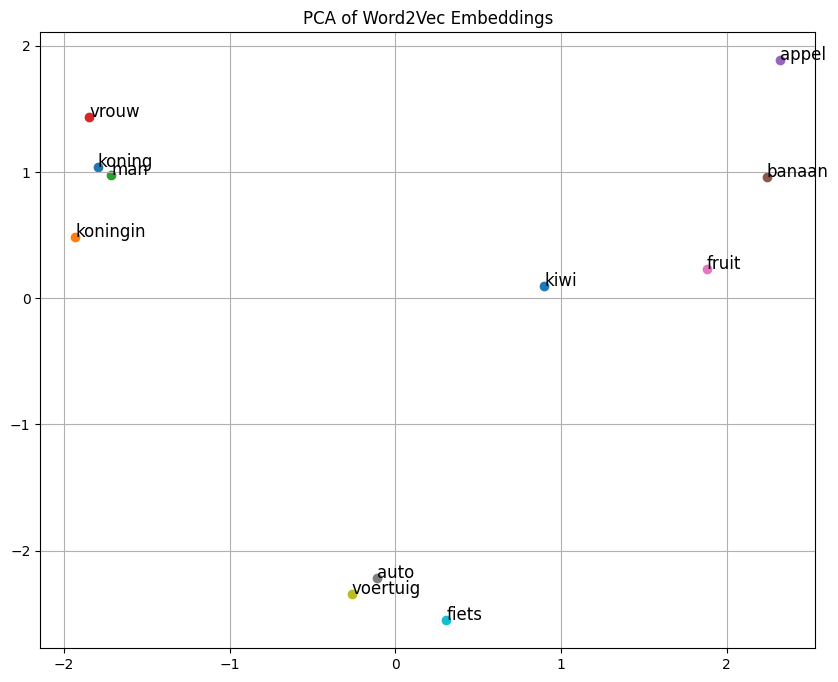

In [39]:
# Get a pca plot of the words 'koning', 'koningin', 'man', 'vrouw', 'appel', 'banaan', 'fruit', 'auto', 'voertuig', 'fiets', 'kiwi'
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Words to visualize
words = ['koning', 'koningin', 'man', 'vrouw', 'appel', 'banaan', 'fruit', 'auto', 'voertuig', 'fiets', 'kiwi']

# Filter out words not in the vocabulary (safety check)
valid_words = [word for word in words if word in model.wv]
vectors = [model.wv[word] for word in valid_words]

# Reduce dimensionality to 2D
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

# Plotting
plt.figure(figsize=(10, 8))
for i, word in enumerate(valid_words):
    plt.scatter(result[i, 0], result[i, 1])
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title('PCA of Word2Vec Embeddings')
plt.grid(True)
plt.show()

In [40]:
import pandas as pd
from scipy.stats import spearmanr

# Load the SimLex-999 Dutch dataset
simlex_path = '/Users/jonasklein/word2vec/SimLex-999-Dutch-final.txt'
df = pd.read_csv(simlex_path, sep='\t')

# Preview dataset
print(df.head())

model_similarities = []
human_similarities = []

for w1, w2, sim in zip(df['word1'], df['word2'], df['SimLex999']):
    if w1 in model.wv.key_to_index and w2 in model.wv.key_to_index:
        model_sim = model.wv.similarity(w1, w2)
    else:
        model_sim = 0.0

    model_similarities.append(model_sim)
    human_similarities.append(sim)

# Now compute Spearman
spearman_corr, _ = spearmanr(model_similarities, human_similarities)
print(f"Spearman correlation between model and human ratings (no filtering): {spearman_corr:.4f}")

      word1        word2  SimLex999 POS
0       oud        nieuw       1.94   A
1      slim  intelligent       8.19   A
2      hard     moeilijk       4.46   A
3  gelukkig      vrolijk       6.49   A
4      hard        stoer       5.69   A
Spearman correlation between model and human ratings (no filtering): 0.2635


In [41]:
coverage = len(model_similarities) / len(df)
print(f"Coverage: {coverage:.2%}")
print(f"Spearman (filtered): {spearman_corr:.4f}")

Coverage: 100.00%
Spearman (filtered): 0.2635


In [42]:
import numpy as np
from scipy.stats import spearmanr

bootstrapped_scores = []
for _ in range(1000):
    indices = np.random.choice(len(model_similarities), size=len(model_similarities), replace=True)
    score, _ = spearmanr(np.array(model_similarities)[indices], np.array(human_similarities)[indices])
    bootstrapped_scores.append(score)

lower = np.percentile(bootstrapped_scores, 2.5)
upper = np.percentile(bootstrapped_scores, 97.5)
print(f"Spearman CI: {np.mean(bootstrapped_scores):.4f} ± ({lower:.4f}, {upper:.4f})")

Spearman CI: 0.2627 ± (0.2067, 0.3197)
